# 신용카드 채무불이행 고객 예측 -

https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

In [2]:
# !pip install xlrd --break-system-packages


In [3]:
import pandas as pd
import urllib.request
import os

os.makedirs('./data', exist_ok=True)

# UCI 원본
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
from pathlib import Path

def find_repo_file(*parts):
    start = Path.cwd().resolve()
    for base in (start, *start.parents):
        candidate = base.joinpath(*parts)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(parts)

XLS_PATH = find_repo_file('05_machine_learning', '03_ml_data', 'tabular_datasets', '../03_ml_data/tabular_datasets/UCI_Credit_Card.xls')
CSV_PATH = find_repo_file('05_machine_learning', '03_ml_data', 'tabular_datasets', '../03_ml_data/tabular_datasets/UCI_Credit_Card.csv')
urllib.request.urlretrieve(url, str(XLS_PATH))

# xls 읽기
df = pd.read_excel(XLS_PATH, header=1)
df.to_csv(CSV_PATH, index=False)
print(df.shape)

# df = pd.read_csv(CSV_PATH)
card_df = df.drop('ID', axis=1)
card_df.head(3)

(30000, 25)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [4]:
card_df = card_df.rename(columns={'default payment next month': 'default'})

y_target = card_df['default']
X_features = card_df.drop('default', axis=1)


# 모델링 프로세스 요약**

**Target** : `default` (0 = 정상, 1 = 채무불이행)

**1단계 EDA**
- 타깃 클래스 비율 확인 (불균형 여부)
- 결측치 · 이상치 탐색
- 주요 피처 분포 및 타깃과의 상관관계 시각화

**2단계 데이터 전처리**
- 범주형 피처 인코딩 (필요 시)
- 수치형 피처 스케일링 (StandardScaler 등)
- 불필요 컬럼 제거

**3단계 Train / Test Split**
- `train_test_split` — `stratify=y` 옵션으로 클래스 비율 유지
- 일반적으로 80 : 20 분할

**4단계 모델 학습**
- Logistic Regression 
- Random Forest (베이스라인)
- XGBoost

**5단계 모델 평가**
- Accuracy, Precision, Recall, F1-Score
- ROC-AUC Curve — 불균형 데이터에서 특히 중요

**6단계 피처 중요도**
- 트리 기반 모델의 feature importance 시각화
- 예측에 영향을 주는 핵심 변수 파악

**7단계 하이퍼파라미터 튜닝 (선택)**
- GridSearchCV 또는 RandomizedSearchCV
- 최적 파라미터로 최종 모델 재학습

**EDA**

In [5]:
# 타깃 클래스 비율 확인
print("=== 타깃 클래스 분포 ===")
print(y_target.value_counts())
print()
print(f"정상(0)     : {y_target.value_counts()[0]:,}명  ({y_target.value_counts(normalize=True)[0]:.1%})")
print(f"채무불이행(1): {y_target.value_counts()[1]:,}명  ({y_target.value_counts(normalize=True)[1]:.1%})")


=== 타깃 클래스 분포 ===
default
0    23364
1     6636
Name: count, dtype: int64

정상(0)     : 23,364명  (77.9%)
채무불이행(1): 6,636명  (22.1%)


In [6]:
# 타깃 클래스 비율 확인
print("=== 타깃 클래스 분포 ===")
print(y_target.value_counts())
print()
print(f"정상(0)     : {y_target.value_counts()[0]:,}명  ({y_target.value_counts(normalize=True)[0]:.1%})")
print(f"채무불이행(1): {y_target.value_counts()[1]:,}명  ({y_target.value_counts(normalize=True)[1]:.1%})")


=== 타깃 클래스 분포 ===
default
0    23364
1     6636
Name: count, dtype: int64

정상(0)     : 23,364명  (77.9%)
채무불이행(1): 6,636명  (22.1%)


**분석 결과**

- 정상(0) : 23,364명 (77.9%)
- 채무불이행(1) : 6,636명 (22.1%)
- 비율 약 4 : 1 → 클래스 불균형(Class Imbalance) 존재

**모델링 시 주의사항**

- Accuracy 만으로는 평가 불충분 → 모델이 전부 0으로 예측해도 77.9% 달성 가능
- Recall, F1-Score, ROC-AUC 를 주요 평가 지표로 사용
- 채무불이행(소수 클래스)을 놓치는 것이 비즈니스 손실이 크므로 Recall 이 특히 중요
- 필요 시 `class_weight='balanced'` 또는 오버샘플링(SMOTE) 적용 고려

In [7]:
# 결측치 확인
print("=== 결측치 확인 ===")
print(X_features.isnull().sum())
print(f"\n총 결측치 수 : {X_features.isnull().sum().sum()}")


=== 결측치 확인 ===
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
dtype: int64

총 결측치 수 : 0


**분석 결과** : 결측치 없음 → 별도 결측치 처리 불필요

In [8]:
# 기술통계 확인
print("=== 기술통계 ===")
X_features.describe()


=== 기술통계 ===


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


# 기술통계 분석 결과**

**이상값 (전처리 필요)**
- `EDUCATION` : 정의된 값은 1~4 (1=대학원, 2=대학, 3=고등학교, 4=기타) → min=0, max=6 으로 **0, 5, 6 은 미정의값** → 4(기타)로 통합 필요
- `MARRIAGE` : 정의된 값은 1~3 (1=기혼, 2=미혼, 3=기타) → min=0 으로 **0 은 미정의값** → 3(기타)으로 통합 필요
- `BILL_AMT` : 음수값 존재 (과납으로 인한 크레딧 잔액) → 이상치 아님, 그대로 유지

**정상 범위 확인**
- `PAY_0 ~ PAY_6` : -2(소비없음), -1(정상납부), 0(리볼빙), 1~8(연체 개월수) → 음수값은 정상
- `AGE` : 21 ~ 79세 → 정상 범위
- `PAY_AMT` : min=0, 최대값 매우 큼 → 극단값 존재하나 실제 납부 데이터로 허용

**전처리 필요 항목 요약**
- `EDUCATION` : 0, 5, 6 → 4 로 통합
- `MARRIAGE` : 0 → 3 으로 통합

C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\4091269730.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='LIMIT_BAL', data=card_df, ax=axes[0, 0], palette=palette)
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\4091269730.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='AGE', data=card_df, ax=axes[0, 1], palette=palette)
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\4091269730.py:45: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\4091269730.py:45: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.


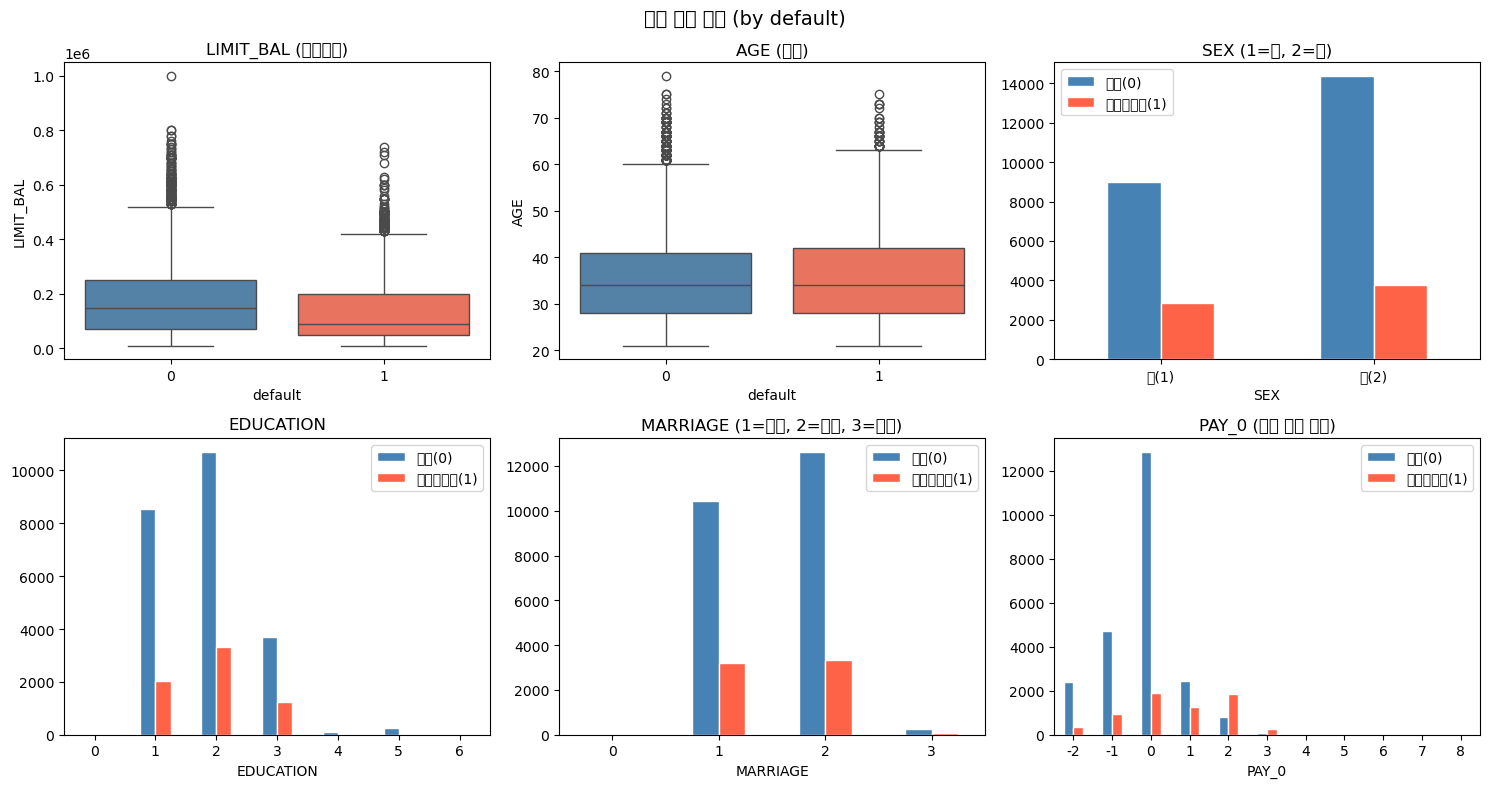

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('주요 피처 분포 (by default)', fontsize=14)

palette = ['steelblue', 'tomato']

# 1. LIMIT_BAL
sns.boxplot(x='default', y='LIMIT_BAL', data=card_df, ax=axes[0, 0], palette=palette)
axes[0, 0].set_title('LIMIT_BAL (신용한도)')

# 2. AGE
sns.boxplot(x='default', y='AGE', data=card_df, ax=axes[0, 1], palette=palette)
axes[0, 1].set_title('AGE (나이)')

# 3. SEX
sex_ratio = card_df.groupby(['SEX', 'default']).size().unstack()
sex_ratio.plot(kind='bar', ax=axes[0, 2], color=palette, edgecolor='white')
axes[0, 2].set_title('SEX (1=남, 2=여)')
axes[0, 2].set_xticklabels(['남(1)', '여(2)'], rotation=0)
axes[0, 2].legend(['정상(0)', '채무불이행(1)'])

# 4. EDUCATION
edu_ratio = card_df.groupby(['EDUCATION', 'default']).size().unstack()
edu_ratio.plot(kind='bar', ax=axes[1, 0], color=palette, edgecolor='white')
axes[1, 0].set_title('EDUCATION')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)
axes[1, 0].legend(['정상(0)', '채무불이행(1)'])

# 5. MARRIAGE
mar_ratio = card_df.groupby(['MARRIAGE', 'default']).size().unstack()
mar_ratio.plot(kind='bar', ax=axes[1, 1], color=palette, edgecolor='white')
axes[1, 1].set_title('MARRIAGE (1=기혼, 2=미혼, 3=기타)')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
axes[1, 1].legend(['정상(0)', '채무불이행(1)'])

# 6. PAY_0 (최근 연체 상태)
pay_ratio = card_df.groupby(['PAY_0', 'default']).size().unstack()
pay_ratio.plot(kind='bar', ax=axes[1, 2], color=palette, edgecolor='white')
axes[1, 2].set_title('PAY_0 (최근 납부 상태)')
axes[1, 2].set_xticklabels(axes[1, 2].get_xticklabels(), rotation=0)
axes[1, 2].legend(['정상(0)', '채무불이행(1)'])

plt.tight_layout()
plt.show()


# 피처 분포 분석 결과**

**LIMIT_BAL (신용한도)**
- 채무불이행(1) 그룹의 중앙값이 정상(0) 그룹보다 낮음
- 신용한도가 낮을수록 채무불이행 가능성 높음 → 예측에 유효한 피처

**AGE (나이)**
- 두 그룹 간 분포 차이 거의 없음 → 예측력 낮을 가능성 있음

**SEX (성별)**
- 여성(2) 이 남성(1) 보다 전체 수가 많음
- 두 그룹 간 채무불이행 비율 큰 차이 없음 → 예측력 낮을 가능성 있음

**EDUCATION**
- 0, 5, 6 미정의값 데이터 수 매우 적음 → 전처리(4로 통합) 필요 재확인
- 대학(2) 비율이 가장 높음

**MARRIAGE**
- 0 미정의값 데이터 수 매우 적음 → 전처리(3으로 통합) 필요 재확인
- 기혼(1), 미혼(2) 간 채무불이행 비율 유사

**PAY_0 (최근 납부 상태) ★ 핵심 피처**
- PAY_0 = 1 이상(연체)일수록 채무불이행(1) 비율이 급격히 증가
- 정상 납부(-1, 0) 구간은 채무불이행 비율 매우 낮음
- PAY_0 이 채무불이행 예측에 가장 영향력 있는 피처로 예상

C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\1814704786.py:11: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\1814704786.py:11: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\1814704786.py:11: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\1814704786.py:11: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\1814704786.py:11: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\1814704786.py:11: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing fr

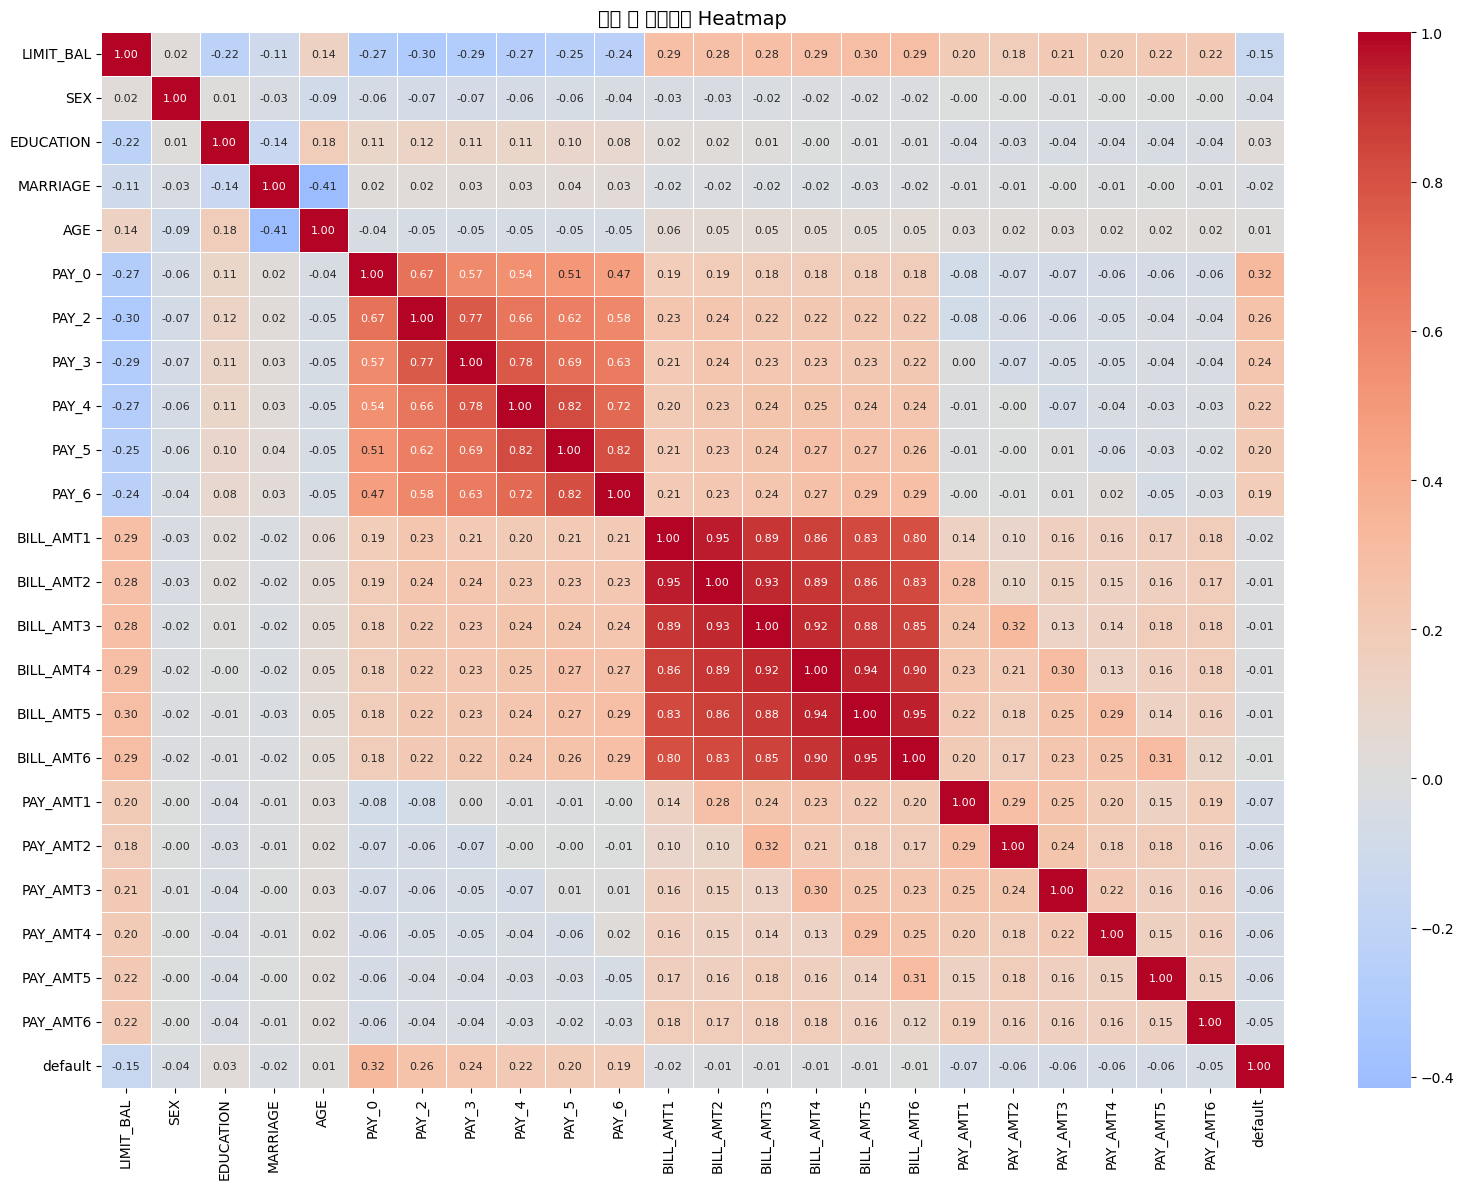

=== default 와의 상관관계 (절대값 내림차순) ===
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
PAY_AMT3     0.056250
PAY_AMT5     0.055124
PAY_AMT6     0.053183
SEX          0.039961
EDUCATION    0.028006
MARRIAGE     0.024339
BILL_AMT1    0.019644
BILL_AMT2    0.014193
BILL_AMT3    0.014076
AGE          0.013890
BILL_AMT4    0.010156
BILL_AMT5    0.006760
BILL_AMT6    0.005372
Name: default, dtype: float64


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 전체 피처 + target 상관관계
corr = card_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('피처 간 상관관계 Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# target과의 상관관계 순위
print("=== default 와의 상관관계 (절대값 내림차순) ===")
print(corr['default'].drop('default').abs().sort_values(ascending=False))


**상관관계 분석 결과**

**default 와의 상관관계 (예측 기여도)**
- `PAY_0` 0.32 → 가장 높음, 핵심 예측 피처
- `PAY_2` 0.26, `PAY_3` 0.24, `PAY_4` 0.22, `PAY_5` 0.20, `PAY_6` 0.19 → 연체 상태 피처군 전반적으로 유효
- `LIMIT_BAL` -0.15 → 신용한도 높을수록 채무불이행 낮음
- `BILL_AMT1~6` : -0.02 ~ -0.01 → 상관관계 거의 없음
- `SEX`, `EDUCATION`, `MARRIAGE`, `AGE` : 0.01 ~ 0.04 → 예측 기여도 매우 낮음

**피처 간 다중공선성 주의**
- `BILL_AMT1 ~ BILL_AMT6` 간 상관계수 0.80 ~ 0.95 → 매우 높음, 다중공선성 존재
- `PAY_0 ~ PAY_6` 간 상관계수 0.47 ~ 0.82 → 높음
- `MARRIAGE` ↔ `AGE` : -0.41 → 음의 상관관계 (나이 많을수록 기혼 비율 높음)

**모델링 시사점**
- `PAY_0 ~ PAY_6` 연체 상태 피처군이 예측에 가장 중요
- `BILL_AMT` 피처군은 다중공선성이 높아 트리 기반 모델에서 중요도가 분산될 수 있음
- `SEX`, `AGE`, `EDUCATION`, `MARRIAGE` 는 예측 기여도 낮으나 제거 여부는 모델 성능 비교 후 결정

**데이터 전처리**

In [11]:
# EDUCATION : 0, 5, 6 → 4 (기타) 로 통합
X_features['EDUCATION'] = X_features['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE : 0 → 3 (기타) 로 통합
X_features['MARRIAGE'] = X_features['MARRIAGE'].replace({0: 3})

# 전처리 결과 확인
print("=== EDUCATION 값 분포 ===")
print(X_features['EDUCATION'].value_counts().sort_index())

print("\n=== MARRIAGE 값 분포 ===")
print(X_features['MARRIAGE'].value_counts().sort_index())


=== EDUCATION 값 분포 ===
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

=== MARRIAGE 값 분포 ===
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


# 추가 전처리 검토 결과**

- 범주형 피처 인코딩 : SEX, EDUCATION, MARRIAGE 는 이미 정수 인코딩 완료 → 추가 인코딩 불필요
- 수치형 피처 스케일링 : Random Forest, XGBoost 는 트리 기반으로 스케일 영향 없음 → Logistic Regression 모델 학습 시에만 StandardScaler 적용
- 불필요 컬럼 제거 : 상관계수 낮은 피처(SEX, AGE 등) 는 현 단계에서 유지, 6단계 피처 중요도 확인 후 제거 여부 결정

**→ 추가 전처리 없이 Train/Test Split 으로 진행**

# **Train / Test Split**

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target,
    test_size=0.2,
    random_state=42,
    stratify=y_target   # 클래스 비율 유지
)

print(f"X_train : {X_train.shape}, X_test : {X_test.shape}")
print(f"y_train 클래스 비율\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\ny_test  클래스 비율\n{y_test.value_counts(normalize=True).round(3)}")


X_train : (24000, 23), X_test : (6000, 23)
y_train 클래스 비율
default
0    0.779
1    0.221
Name: proportion, dtype: float64

y_test  클래스 비율
default
0    0.779
1    0.221
Name: proportion, dtype: float64


# 모델 학습**

베이스라인 : Random Forest Classifier (class_weight 미적용)
비교 1 : Random Forest Classifier (class_weight='balanced')
비교 2 : Random Forest Classifier + SMOTE 오버샘플링

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 베이스라인 RFC (class_weight 미적용)
rfc_base = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_base.fit(X_train, y_train)

y_pred_base = rfc_base.predict(X_test)
y_prob_base = rfc_base.predict_proba(X_test)[:, 1]

print("=== 베이스라인 RFC ===")
print(classification_report(y_test, y_pred_base, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_base):.4f}")


=== 베이스라인 RFC ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.94      0.89      4673
    채무불이행(1)       0.64      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.80      0.81      0.79      6000

ROC-AUC : 0.7572


# 베이스라인 RFC 결과 분석**

| 구분 | Precision | Recall | F1-Score |
|------|-----------|--------|----------|
| 정상(0) | 0.84 | 0.94 | 0.89 |
| 채무불이행(1) | 0.64 | 0.36 | 0.46 |
- Accuracy : 0.81 / ROC-AUC : 0.7572

**문제점**
- 채무불이행(1) Recall = 0.36 → 실제 채무불이행 고객 중 64%를 정상으로 잘못 분류
- 클래스 불균형(4:1)의 영향으로 모델이 다수 클래스(정상)에 편향
- Accuracy 0.81은 높아 보이나 신뢰 불가 → 불균형 데이터에서 무의미한 지표

**→ class_weight='balanced' 적용으로 Recall 개선 시도**

In [14]:
# 비교 1 : RFC + class_weight='balanced'
rfc_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rfc_balanced.fit(X_train, y_train)

y_pred_bal = rfc_balanced.predict(X_test)
y_prob_bal = rfc_balanced.predict_proba(X_test)[:, 1]

print("=== RFC (class_weight='balanced') ===")
print(classification_report(y_test, y_pred_bal, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_bal):.4f}")


=== RFC (class_weight='balanced') ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.95      0.89      4673
    채무불이행(1)       0.64      0.34      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.67      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC : 0.7583


# **RFC class_weight='balanced' 결과 분석**

| 구분 | 베이스라인 | class_weight='balanced' | 변화 |
|------|-----------|------------------------|------|
| 채무불이행 Recall | 0.36 | 0.34 | ↓ |
| 채무불이행 F1 | 0.46 | 0.45 | ↓ |
| ROC-AUC | 0.7572 | 0.7583 | ↑ (미미) |

**결과 해석**
- class_weight='balanced' 적용에도 채무불이행 Recall 개선 없음 (오히려 소폭 하락)
- RFC 는 다수의 트리로 구성되어 class_weight 효과가 제한적으로 작용한 것으로 판단
- ROC-AUC 는 0.7572 → 0.7583 으로 거의 동일

**→ SMOTE 오버샘플링 적용으로 Recall 개선 시도**

In [15]:
from imblearn.over_sampling import SMOTE

# SMOTE 적용 (train 데이터에만)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("=== SMOTE 적용 후 train 클래스 분포 ===")
print(y_train_smote.value_counts())
print(f"\n정상(0)     : {y_train_smote.value_counts()[0]:,}명")
print(f"채무불이행(1): {y_train_smote.value_counts()[1]:,}명")


=== SMOTE 적용 후 train 클래스 분포 ===
default
0    18691
1    18691
Name: count, dtype: int64

정상(0)     : 18,691명
채무불이행(1): 18,691명


In [16]:
# 비교 2 : RFC + SMOTE
rfc_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rfc_smote.predict(X_test)
y_prob_smote = rfc_smote.predict_proba(X_test)[:, 1]

print("\n=== RFC + SMOTE ===")
print(classification_report(y_test, y_pred_smote, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_smote):.4f}")



=== RFC + SMOTE ===
              precision    recall  f1-score   support

       정상(0)       0.85      0.87      0.86      4673
    채무불이행(1)       0.51      0.48      0.49      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.67      0.68      6000
weighted avg       0.78      0.78      0.78      6000

ROC-AUC : 0.7443


# **3개 모델 비교 결과 (채무불이행(1) 기준)**

| 모델 | Precision | Recall | F1-Score | ROC-AUC |
|------|-----------|--------|----------|---------|
| 베이스라인 RFC | 0.64 | 0.36 | 0.46 | 0.7572 |
| RFC + class_weight='balanced' | 0.64 | 0.34 | 0.45 | 0.7583 |
| RFC + SMOTE | 0.51 | **0.48** | **0.49** | 0.7443 |

**결과 해석**
- SMOTE 적용 시 Recall 0.36 → 0.48 로 가장 큰 개선 (+0.12)
- 단, Precision 0.64 → 0.51 로 하락 → 정상 고객을 채무불이행으로 잘못 분류하는 비율 증가
- ROC-AUC 는 세 모델 모두 0.74 ~ 0.76 수준으로 유사
- 채무불이행 탐지(Recall) 관점에서는 SMOTE 모델이 가장 우수

**→ 채무불이행 탐지가 목적인 비즈니스 관점에서 RFC + SMOTE 를 최종 모델로 선택**

# **피처 중요도 시각화**

RFC + SMOTE 최종 모델의 feature importance를 시각화하여 채무불이행 예측에 가장 영향력 있는 변수를 파악한다.

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# RFC + SMOTE 모델의 피처 중요도
fi_smote = pd.Series(rfc_smote.feature_importances_, index=X_features.columns).sort_values(ascending=False)
fi_smote[:3]

PAY_0        0.080563
LIMIT_BAL    0.061405
BILL_AMT1    0.057868
dtype: float64

In [18]:
# 베이스라인 RFC 피처 중요도 (비교용)
fi_base = pd.Series(rfc_base.feature_importances_, index=X_features.columns).sort_values(ascending=False)
fi_base[:3]

PAY_0        0.101611
AGE          0.065899
LIMIT_BAL    0.061083
dtype: float64

C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\686914440.py:22: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\686914440.py:22: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\686914440.py:22: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\686914440.py:22: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\686914440.py:22: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\686914440.py:22: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(

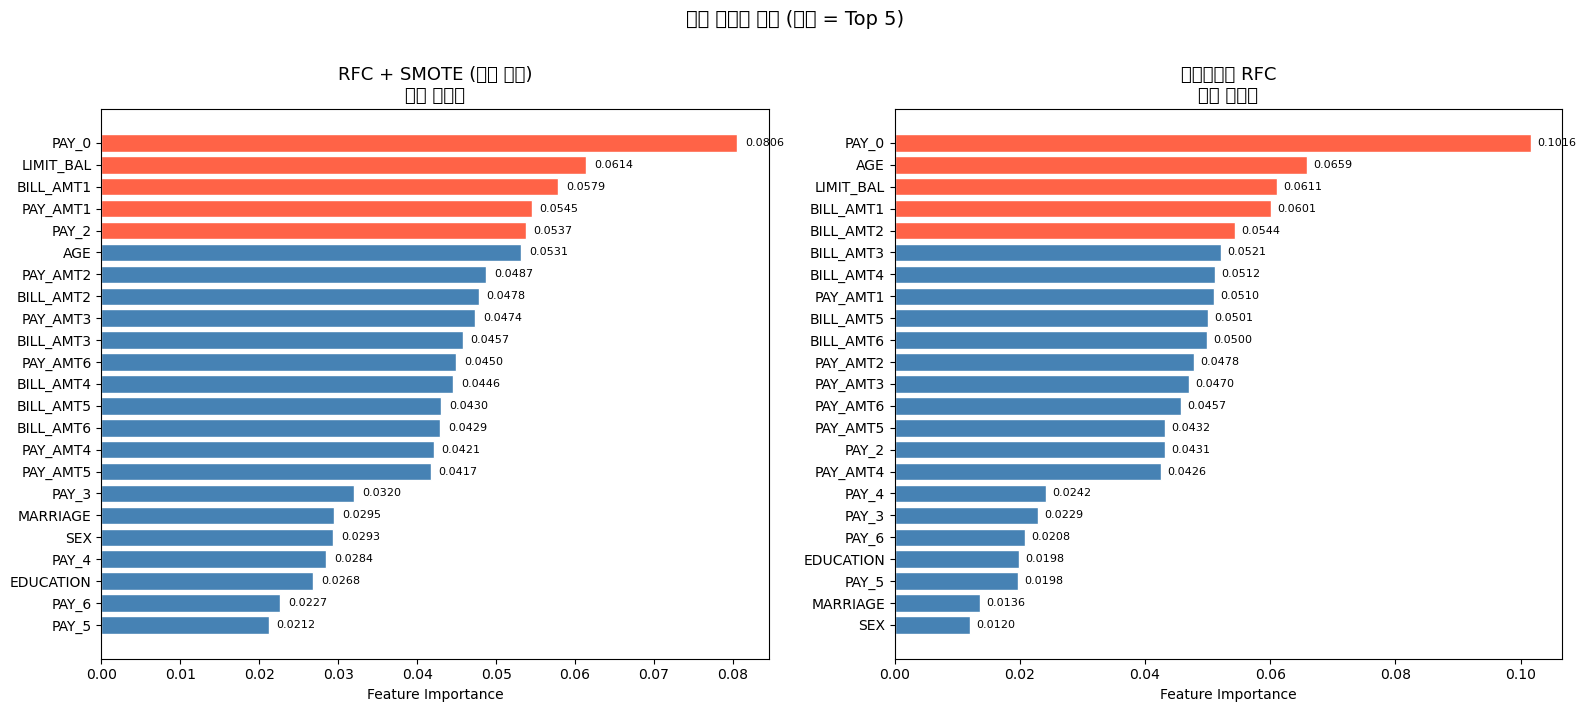

In [19]:
# 시각화

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = ['tomato' if i < 5 else 'steelblue' for i in range(len(fi_smote))]

# RFC + SMOTE 피처 중요도
axes[0].barh(fi_smote.index[::-1], fi_smote.values[::-1], color=colors[::-1], edgecolor='white')
axes[0].set_title('RFC + SMOTE (최종 모델)\n피처 중요도', fontsize=13)
axes[0].set_xlabel('Feature Importance')
for i, (val, name) in enumerate(zip(fi_smote.values[::-1], fi_smote.index[::-1])):
    axes[0].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)

# 베이스라인 RFC 피처 중요도
colors_base = ['tomato' if i < 5 else 'steelblue' for i in range(len(fi_base))]
axes[1].barh(fi_base.index[::-1], fi_base.values[::-1], color=colors_base[::-1], edgecolor='white')
axes[1].set_title('베이스라인 RFC\n피처 중요도', fontsize=13)
axes[1].set_xlabel('Feature Importance')
for i, (val, name) in enumerate(zip(fi_base.values[::-1], fi_base.index[::-1])):
    axes[1].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('피처 중요도 비교 (빨강 = Top 5)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [20]:
# 수치 출력
print("=== RFC + SMOTE 피처 중요도 Top 10 ===")
print(fi_smote.head(10).to_string())
print("\n=== 베이스라인 RFC 피처 중요도 Top 10 ===")
print(fi_base.head(10).to_string())


=== RFC + SMOTE 피처 중요도 Top 10 ===
PAY_0        0.080563
LIMIT_BAL    0.061405
BILL_AMT1    0.057868
PAY_AMT1     0.054495
PAY_2        0.053729
AGE          0.053141
PAY_AMT2     0.048713
BILL_AMT2    0.047785
PAY_AMT3     0.047380
BILL_AMT3    0.045746

=== 베이스라인 RFC 피처 중요도 Top 10 ===
PAY_0        0.101611
AGE          0.065899
LIMIT_BAL    0.061083
BILL_AMT1    0.060092
BILL_AMT2    0.054373
BILL_AMT3    0.052137
BILL_AMT4    0.051167
PAY_AMT1     0.050959
BILL_AMT5    0.050104
BILL_AMT6    0.049971


**피처 중요도 분석 결과**

**RFC + SMOTE vs 베이스라인 RFC — Top 10 비교**

| 순위 | RFC + SMOTE | 중요도 | 베이스라인 RFC | 중요도 |
|------|-------------|--------|---------------|--------|
| 1 | PAY_0 | 0.0806 | PAY_0 | 0.1016 |
| 2 | LIMIT_BAL | 0.0614 | AGE | 0.0659 |
| 3 | BILL_AMT1 | 0.0579 | LIMIT_BAL | 0.0611 |
| 4 | PAY_AMT1 | 0.0545 | BILL_AMT1 | 0.0601 |
| 5 | PAY_2 | 0.0537 | BILL_AMT2 | 0.0544 |
| 6 | AGE | 0.0531 | BILL_AMT3 | 0.0521 |
| 7 | PAY_AMT2 | 0.0487 | BILL_AMT4 | 0.0512 |
| 8 | BILL_AMT2 | 0.0478 | PAY_AMT1 | 0.0510 |
| 9 | PAY_AMT3 | 0.0474 | BILL_AMT5 | 0.0501 |
| 10 | BILL_AMT3 | 0.0457 | BILL_AMT6 | 0.0500 |

**주요 분석 포인트**

- **PAY_0 압도적 1위 유지** — 두 모델 모두 1위이며 EDA 상관관계(0.32)와 일치. 단, SMOTE 모델에서는 0.1016 → 0.0806으로 중요도 집중도가 완화됨 (전체 피처 간 분산 효과)
- **AGE 순위 급변 (베이스라인 2위 → SMOTE 6위)** — AGE는 EDA에서 상관계수 ~0.04로 낮았음에도 베이스라인에서 2위. 이는 MDI(불순도 감소) 기반 feature importance가 연속형 고유값 수가 많은 변수에 편향되는 한계. SMOTE로 소수 클래스가 보강되자 실제 예측력이 낮은 AGE의 중요도가 6위로 하락 → **SMOTE가 편향 완화에 기여**
- **BILL_AMT 계열 — EDA와 불일치** — 상관관계 분석(-0.02 ~ -0.01)에서는 거의 무관했으나 두 모델 모두 Top 10에 다수 등장. BILL_AMT1~6 간 다중공선성(0.80~0.95)이 높아 트리 분기 시 여러 BILL_AMT 피처가 중복 사용되며 중요도가 분산된 것으로 해석
- **SMOTE 모델에서 PAY_AMT 계열 상승** — 실납부액(PAY_AMT1~3)이 Top 10 내 3개 진입, 베이스라인보다 상위권. SMOTE로 채무불이행 패턴이 보강되면서 납부 능력을 나타내는 피처 학습 강화
- **SMOTE 모델 전반적 중요도 평탄화** — 1위 PAY_0 외 나머지 피처들의 중요도 격차 축소 (0.046~0.061 수준). 특정 피처 쏠림 없이 고르게 학습됨을 의미

# **XGBoost 추가 비교**

XGBoost 베이스라인 / XGBoost + SMOTE 를 학습하고, 앞서 학습한 RFC 3종과 전체 비교한다.

In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# --- XGBoost 베이스라인 ---
xgb_base = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_base.fit(X_train, y_train)

y_pred_xgb = xgb_base.predict(X_test)
y_prob_xgb = xgb_base.predict_proba(X_test)[:, 1]

print("=== XGBoost 베이스라인 ===")
print(classification_report(y_test, y_pred_xgb, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_xgb):.4f}")


=== XGBoost 베이스라인 ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.94      0.88      4673
    채무불이행(1)       0.61      0.36      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.72      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC : 0.7601


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:49:16] WARNING: D:\bld\xgboost-split_1770963345048\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [22]:
# --- XGBoost + SMOTE ---
# 클래스 불균형 비율 계산 (scale_pos_weight 대신 SMOTE 사용)
xgb_smote = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test)
y_prob_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]

print("=== XGBoost + SMOTE ===")
print(classification_report(y_test, y_pred_xgb_smote, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_xgb_smote):.4f}")


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:49:17] WARNING: D:\bld\xgboost-split_1770963345048\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost + SMOTE ===
              precision    recall  f1-score   support

       정상(0)       0.85      0.84      0.85      4673
    채무불이행(1)       0.46      0.47      0.46      1327

    accuracy                           0.76      6000
   macro avg       0.65      0.65      0.65      6000
weighted avg       0.76      0.76      0.76      6000

ROC-AUC : 0.7330


In [23]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# 전체 5개 모델 비교 요약표 (채무불이행(1) 기준)
models = {
    'RFC 베이스라인':       (y_test, y_pred_base,      y_prob_base),
    'RFC + balanced':      (y_test, y_pred_bal,       y_prob_bal),
    'RFC + SMOTE':         (y_test, y_pred_smote,     y_prob_smote),
    'XGBoost 베이스라인':  (y_test, y_pred_xgb,       y_prob_xgb),
    'XGBoost + SMOTE':     (y_test, y_pred_xgb_smote, y_prob_xgb_smote),
}

rows = []
for name, (yt, yp, yprob) in models.items():
    rows.append({
        '모델': name,
        'Precision': round(precision_score(yt, yp, pos_label=1), 4),
        'Recall':    round(recall_score(yt, yp, pos_label=1), 4),
        'F1-Score':  round(f1_score(yt, yp, pos_label=1), 4),
        'ROC-AUC':   round(roc_auc_score(yt, yprob), 4),
    })

summary = pd.DataFrame(rows).set_index('모델')
print("=== 전체 모델 비교 (채무불이행(1) 기준) ===")
print(summary.to_string())


=== 전체 모델 비교 (채무불이행(1) 기준) ===
                 Precision  Recall  F1-Score  ROC-AUC
모델                                                   
RFC 베이스라인           0.6429  0.3595    0.4611   0.7572
RFC + balanced      0.6450  0.3436    0.4484   0.7583
RFC + SMOTE         0.5105  0.4770    0.4932   0.7443
XGBoost 베이스라인       0.6121  0.3580    0.4517   0.7601
XGBoost + SMOTE     0.4574  0.4657    0.4615   0.7330


**전체 모델 비교 분석 결과**

**5개 모델 성능 비교 (채무불이행(1) 기준)**

| 모델 | Precision | Recall | F1-Score | ROC-AUC |
|------|-----------|--------|----------|---------|
| RFC 베이스라인 | 0.6429 | 0.3595 | 0.4611 | 0.7572 |
| RFC + balanced | 0.6450 | 0.3436 | 0.4484 | 0.7583 |
| **RFC + SMOTE** | 0.5105 | **0.4770** | **0.4932** | 0.7443 |
| **XGBoost 베이스라인** | 0.6121 | 0.3580 | 0.4517 | **0.7601** |
| XGBoost + SMOTE | 0.4574 | 0.4657 | 0.4615 | 0.7330 |

**지표별 최고 모델**
- Recall 최고 : **RFC + SMOTE (0.4770)** → 채무불이행 고객 탐지율 가장 우수
- F1-Score 최고 : **RFC + SMOTE (0.4932)** → Precision / Recall 균형 최고
- ROC-AUC 최고 : **XGBoost 베이스라인 (0.7601)** → 확률 예측 품질 최고

**XGBoost 분석**
- XGBoost 베이스라인은 ROC-AUC 0.7601로 5개 모델 중 최고 → 확률 추정 성능이 RFC보다 우수
- 단, Recall 0.3580으로 RFC 베이스라인(0.3595)과 거의 동일 → 클래스 불균형 처리 없이는 RFC와 유사한 한계
- **XGBoost + SMOTE 에서 ROC-AUC 0.7330으로 급락** → SMOTE 합성 데이터가 XGBoost 부스팅 과정에서 과적합 또는 노이즈로 작용한 것으로 판단 (RFC는 SMOTE 적용 시 ROC-AUC 소폭 하락에 그쳤으나, XGBoost는 -0.027 큰 폭 하락)

**비즈니스 관점 최종 모델 선택**
- 채무불이행 탐지(Recall) 최우선 → **RFC + SMOTE** (Recall 0.4770, F1 0.4932)
- 확률 스코어링 활용 (임계값 조정) → **XGBoost 베이스라인** (ROC-AUC 0.7601) 검토 가능

**→ 다음 단계 : XGBoost 베이스라인의 분류 임계값(threshold)을 낮춰 Recall 개선 시도 또는 하이퍼파라미터 튜닝**

# **PCA 차원축소 — 연체 고객 패턴 분석**

StandardScaler 스케일링 후 PCA를 적용하여 채무불이행 고객과 정상 고객의 분포 패턴을 시각화한다.

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. 스케일링 (PCA는 스케일에 민감)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# 2. PCA 전체 성분으로 먼저 적합 → 분산 설명력 확인
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumsum_var    = np.cumsum(explained_var)

# 수치 출력
print("=== PC별 분산 설명 비율 ===")
for i, (ev, cv) in enumerate(zip(explained_var, cumsum_var), 1):
    print(f"PC{i:2d} : {ev:.4f}  (누적 {cv:.4f})")


=== PC별 분산 설명 비율 ===
PC 1 : 0.2845  (누적 0.2845)
PC 2 : 0.1784  (누적 0.4629)
PC 3 : 0.0674  (누적 0.5303)
PC 4 : 0.0640  (누적 0.5943)
PC 5 : 0.0445  (누적 0.6388)
PC 6 : 0.0417  (누적 0.6805)
PC 7 : 0.0394  (누적 0.7199)
PC 8 : 0.0386  (누적 0.7585)
PC 9 : 0.0379  (누적 0.7964)
PC10 : 0.0340  (누적 0.8304)
PC11 : 0.0319  (누적 0.8622)
PC12 : 0.0297  (누적 0.8919)
PC13 : 0.0250  (누적 0.9169)
PC14 : 0.0226  (누적 0.9394)
PC15 : 0.0175  (누적 0.9570)
PC16 : 0.0113  (누적 0.9683)
PC17 : 0.0108  (누적 0.9791)
PC18 : 0.0082  (누적 0.9873)
PC19 : 0.0057  (누적 0.9931)
PC20 : 0.0031  (누적 0.9961)
PC21 : 0.0018  (누적 0.9979)
PC22 : 0.0011  (누적 0.9990)
PC23 : 0.0010  (누적 1.0000)


**PCA 분산 설명력 분석 결과**

| 기준 | 필요 PC 수 | 누적 설명력 |
|------|-----------|------------|
| 2D 시각화 | PC1~2 | 46.3% |
| 80% 설명 | PC1~9 | 79.6% |
| 90% 설명 | PC1~12 | 89.2% |
| 95% 설명 | PC1~15 | 95.7% |

- **PC1 (28.5%) 압도적 1위** — BILL_AMT1~6 간 다중공선성(0.80~0.95)이 높아 청구금액 변동을 PC1 하나로 압축한 것으로 예상
- **PC2 (17.8%)** — PAY_0~6 연체 상태 피처군을 반영할 가능성 높음 (EDA에서 PAY 계열 간 상관관계 0.47~0.82)
- **PC3 이후 급격히 감소** → PC1~2 이후 설명력이 분산되는 elbow 구간
- **2D 시각화(PC1+PC2=46.3%)로는 원본 분산의 절반 이하만 보존** → 군집 분리가 뚜렷하지 않을 수 있음
- **연체 고객 패턴 분석 목적이라면 PC9(누적 79.6%)~PC12(누적 89.2%) 수준이 적절**

**→ 다음 단계 : PC1·PC2 loadings 확인으로 각 주성분의 피처 구성 파악 + 2D 산점도로 정상/채무불이행 분포 비교**

C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\2043411953.py:20: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\2043411953.py:20: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\2043411953.py:20: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\2043411953.py:20: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\2043411953.py:20: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\2043411953.py:20: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from 

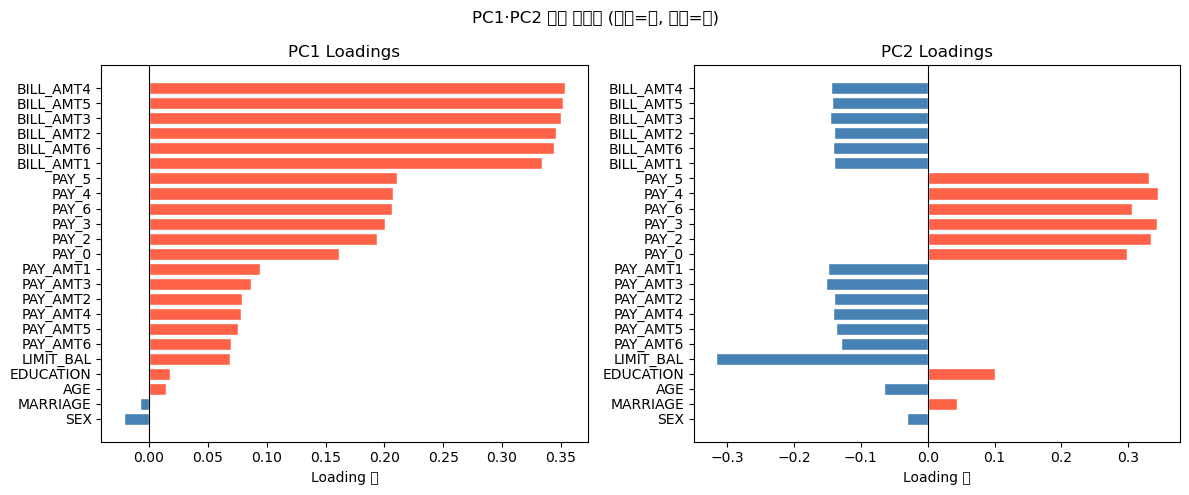

                PC1       PC2
SEX       -0.021657 -0.030489
MARRIAGE  -0.007381  0.043819
AGE        0.014357 -0.065758
EDUCATION  0.018213  0.099909
LIMIT_BAL  0.068564 -0.316486
PAY_AMT6   0.069941 -0.129418
PAY_AMT5   0.075354 -0.137133
PAY_AMT4   0.077801 -0.141267
PAY_AMT2   0.078686 -0.139712
PAY_AMT3   0.086394 -0.151444
PAY_AMT1   0.094231 -0.148933
PAY_0      0.161079  0.297888
PAY_2      0.194115  0.334570
PAY_3      0.200207  0.343613
PAY_6      0.206408  0.305466
PAY_4      0.207033  0.344254
PAY_5      0.210953  0.331244
BILL_AMT1  0.334383 -0.139651
BILL_AMT6  0.344526 -0.141683
BILL_AMT2  0.345795 -0.140056
BILL_AMT3  0.349779 -0.146035
BILL_AMT5  0.351761 -0.143596
BILL_AMT4  0.353888 -0.145286


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# PC1, PC2 loadings
loadings = pd.DataFrame(
    pca_full.components_[:2].T,
    index=X_features.columns,
    columns=['PC1', 'PC2']
).sort_values('PC1')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ['PC1', 'PC2']):
    colors = ['tomato' if v > 0 else 'steelblue' for v in loadings[col]]
    ax.barh(loadings.index, loadings[col], color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{col} Loadings')
    ax.set_xlabel('Loading 값')

plt.suptitle('PC1·PC2 피처 기여도 (빨강=양, 파랑=음)', fontsize=12)
plt.tight_layout()
plt.show()

print(loadings.to_string())


- 

C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\2222994829.py:33: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\2222994829.py:33: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\2222994829.py:33: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\2222994829.py:33: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\2222994829.py:33: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\2222994829.py:33: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing fro

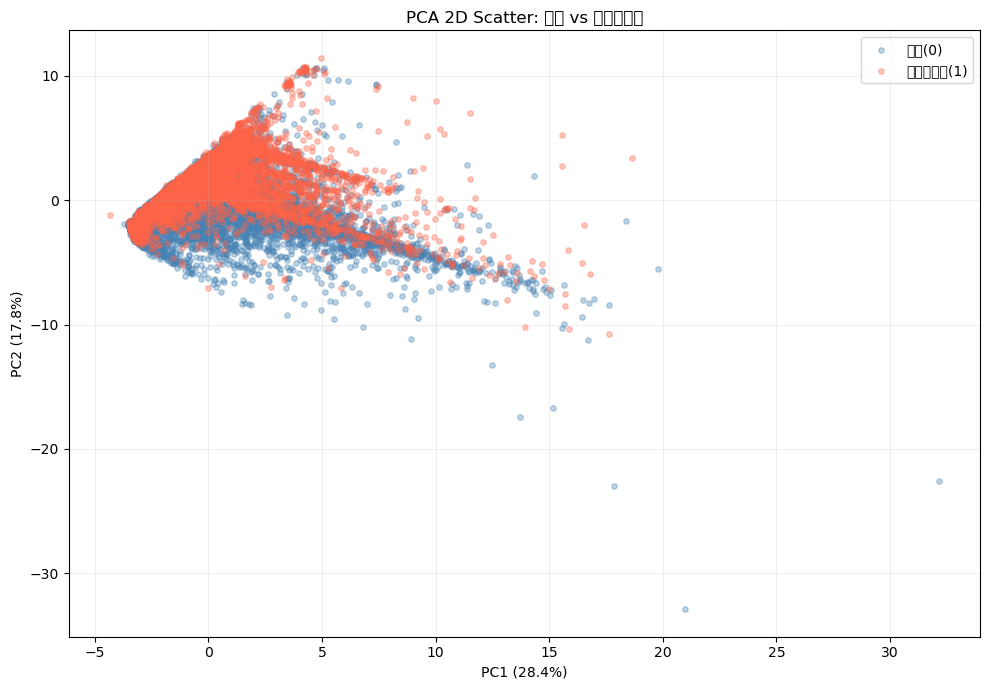

PC1 설명력: 0.2845
PC2 설명력: 0.1784
누적 설명력: 0.4629


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PC1, PC2로 축소
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# 시각화용 데이터프레임
pca_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
pca_df['default'] = y_target.values

# 산점도
plt.figure(figsize=(10, 7))

normal = pca_df[pca_df['default'] == 0]
default = pca_df[pca_df['default'] == 1]

plt.scatter(
    normal['PC1'], normal['PC2'],
    s=15, alpha=0.35, label='정상(0)', c='steelblue'
)
plt.scatter(
    default['PC1'], default['PC2'],
    s=15, alpha=0.35, label='채무불이행(1)', c='tomato'
)

plt.title('PCA 2D Scatter: 정상 vs 채무불이행')
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 참고용 수치 출력
print("PC1 설명력:", round(pca_2d.explained_variance_ratio_[0], 4))
print("PC2 설명력:", round(pca_2d.explained_variance_ratio_[1], 4))
print("누적 설명력:", round(pca_2d.explained_variance_ratio_.sum(), 4))


In [27]:
# 클래스별 PC1, PC2 분포 요약
pca_summary = pca_df.groupby('default')[['PC1', 'PC2']].agg(['mean', 'std', 'median'])
print(pca_summary)

              PC1                           PC2                    
             mean       std    median      mean       std    median
default                                                            
0       -0.114880  2.508112 -0.561360 -0.307045  1.808609 -0.224231
1        0.404469  2.687666  0.024745  1.081043  2.352848  1.045279


In [28]:
from scipy.stats import ttest_ind

pc1_0 = pca_df[pca_df['default'] == 0]['PC1']
pc1_1 = pca_df[pca_df['default'] == 1]['PC1']

pc2_0 = pca_df[pca_df['default'] == 0]['PC2']
pc2_1 = pca_df[pca_df['default'] == 1]['PC2']

t_pc1, p_pc1 = ttest_ind(pc1_0, pc1_1, equal_var=False)
t_pc2, p_pc2 = ttest_ind(pc2_0, pc2_1, equal_var=False)

print(f"PC1 t-statistic: {t_pc1:.4f}, p-value: {p_pc1:.10f}")
print(f"PC2 t-statistic: {t_pc2:.4f}, p-value: {p_pc2:.10f}")

PC1 t-statistic: -14.0943, p-value: 0.0000000000
PC2 t-statistic: -44.4720, p-value: 0.0000000000


In [29]:
pc2_loading = loadings['PC2'].sort_values(key=lambda x: x.abs(), ascending=False)
print(pc2_loading)

PAY_4        0.344254
PAY_3        0.343613
PAY_2        0.334570
PAY_5        0.331244
LIMIT_BAL   -0.316486
PAY_6        0.305466
PAY_0        0.297888
PAY_AMT3    -0.151444
PAY_AMT1    -0.148933
BILL_AMT3   -0.146035
BILL_AMT4   -0.145286
BILL_AMT5   -0.143596
BILL_AMT6   -0.141683
PAY_AMT4    -0.141267
BILL_AMT2   -0.140056
PAY_AMT2    -0.139712
BILL_AMT1   -0.139651
PAY_AMT5    -0.137133
PAY_AMT6    -0.129418
EDUCATION    0.099909
AGE         -0.065758
MARRIAGE     0.043819
SEX         -0.030489
Name: PC2, dtype: float64


In [30]:
# PC2 구간별 채무불이행률 확인
pc2_risk = pca_df.copy()
pc2_risk['PC2_bin'] = pd.qcut(pc2_risk['PC2'], q=10, duplicates='drop')

risk_table = pc2_risk.groupby('PC2_bin')['default'].agg(['count', 'mean'])
risk_table = risk_table.rename(columns={'count': 'sample_count', 'mean': 'default_rate'})

print(risk_table)


                   sample_count  default_rate
PC2_bin                                      
(-32.887, -2.414]          3000      0.133667
(-2.414, -1.52]            3000      0.147667
(-1.52, -0.927]            3000      0.135667
(-0.927, -0.48]            3000      0.143000
(-0.48, 0.00236]           3000      0.156333
(0.00236, 0.485]           3000      0.146667
(0.485, 0.898]             3000      0.162333
(0.898, 1.298]             3000      0.205667
(1.298, 2.328]             3000      0.366000
(2.328, 11.449]            3000      0.615000


In [31]:
import statsmodels.api as sm
import numpy as np

X_pc2 = sm.add_constant(pca_df['PC2'])
y_pc2 = pca_df['default']

logit_model = sm.Logit(y_pc2, X_pc2).fit()
print(logit_model.summary())

odds_ratio = np.exp(logit_model.params)
print("\nOdds Ratio")
print(odds_ratio)


Optimization terminated successfully.
         Current function value: 0.486167
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                30000
Model:                          Logit   Df Residuals:                    29998
Method:                           MLE   Df Model:                            1
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                 0.07996
Time:                        11:54:12   Log-Likelihood:                -14585.
converged:                       True   LL-Null:                       -15853.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3914      0.015    -90.302      0.000      -1.422      -1.361
PC2            0.3731      0.

In [32]:
from sklearn.metrics import roc_auc_score

pca_df['pc2_prob'] = logit_model.predict(X_pc2)
auc_pc2 = roc_auc_score(y_pc2, pca_df['pc2_prob'])

print(f"PC2 단독 로지스틱 회귀 ROC-AUC: {auc_pc2:.4f}")


PC2 단독 로지스틱 회귀 ROC-AUC: 0.6846


In [33]:
pc2_corr = X_features.copy()
pc2_corr['PC2'] = pca_df['PC2']

corr_with_pc2 = pc2_corr.corr(numeric_only=True)['PC2'].sort_values(key=lambda x: x.abs(), ascending=False)
print(corr_with_pc2)


PC2          1.000000
PAY_4        0.697374
PAY_3        0.696077
PAY_2        0.677756
PAY_5        0.671019
LIMIT_BAL   -0.641124
PAY_6        0.618800
PAY_0        0.603447
PAY_AMT3    -0.306789
PAY_AMT1    -0.301703
BILL_AMT3   -0.295831
BILL_AMT4   -0.294315
BILL_AMT5   -0.290890
BILL_AMT6   -0.287016
PAY_AMT4    -0.286172
BILL_AMT2   -0.283719
PAY_AMT2    -0.283022
BILL_AMT1   -0.282898
PAY_AMT5    -0.277797
PAY_AMT6    -0.262169
EDUCATION    0.202392
AGE         -0.133209
MARRIAGE     0.088766
SEX         -0.061763
Name: PC2, dtype: float64


In [34]:
from sklearn.metrics import roc_auc_score

auc_pay0 = roc_auc_score(y_target, X_features['PAY_0'])
print(f"PAY_0 단독 ROC-AUC: {auc_pay0:.4f}")


PAY_0 단독 ROC-AUC: 0.6897


In [35]:
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score

X_two = sm.add_constant(pd.DataFrame({
    'PAY_0': X_features['PAY_0'],
    'PC2': pca_df['PC2']
}))
y_two = y_target

logit_two = sm.Logit(y_two, X_two).fit()
print(logit_two.summary())

pred_two = logit_two.predict(X_two)
auc_two = roc_auc_score(y_two, pred_two)
print(f"\nPAY_0 + PC2 ROC-AUC: {auc_two:.4f}")


Optimization terminated successfully.
         Current function value: 0.468665
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                30000
Model:                          Logit   Df Residuals:                    29997
Method:                           MLE   Df Model:                            2
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                  0.1131
Time:                        12:13:57   Log-Likelihood:                -14060.
converged:                       True   LL-Null:                       -15853.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4267      0.016    -90.076      0.000      -1.458      -1.396
PAY_0          0.5497      0.

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# 1. PAY_0 단독
X_pay0 = X_features[['PAY_0']]
model_pay0 = LogisticRegression(max_iter=1000, random_state=42)
model_pay0.fit(X_pay0, y_target)

pred_pay0 = model_pay0.predict(X_pay0)
prob_pay0 = model_pay0.predict_proba(X_pay0)[:, 1]

print("=== PAY_0 단독 ===")
print(confusion_matrix(y_target, pred_pay0))
print(classification_report(y_target, pred_pay0, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC: {roc_auc_score(y_target, prob_pay0):.4f}")

# 2. PAY_0 + PC2
X_pay0_pc2 = pd.DataFrame({
    'PAY_0': X_features['PAY_0'],
    'PC2': pca_df['PC2']
})
model_pay0_pc2 = LogisticRegression(max_iter=1000, random_state=42)
model_pay0_pc2.fit(X_pay0_pc2, y_target)

pred_pay0_pc2 = model_pay0_pc2.predict(X_pay0_pc2)
prob_pay0_pc2 = model_pay0_pc2.predict_proba(X_pay0_pc2)[:, 1]

print("\n=== PAY_0 + PC2 ===")
print(confusion_matrix(y_target, pred_pay0_pc2))
print(classification_report(y_target, pred_pay0_pc2, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC: {roc_auc_score(y_target, prob_pay0_pc2):.4f}")


=== PAY_0 단독 ===
[[22411   953]
 [ 4459  2177]]
              precision    recall  f1-score   support

       정상(0)       0.83      0.96      0.89     23364
    채무불이행(1)       0.70      0.33      0.45      6636

    accuracy                           0.82     30000
   macro avg       0.76      0.64      0.67     30000
weighted avg       0.80      0.82      0.79     30000

ROC-AUC: 0.6897

=== PAY_0 + PC2 ===
[[22759   605]
 [ 5117  1519]]
              precision    recall  f1-score   support

       정상(0)       0.82      0.97      0.89     23364
    채무불이행(1)       0.72      0.23      0.35      6636

    accuracy                           0.81     30000
   macro avg       0.77      0.60      0.62     30000
weighted avg       0.79      0.81      0.77     30000

ROC-AUC: 0.7155


In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

rows = []
for th in thresholds:
    pred_th = (prob_pay0_pc2 >= th).astype(int)
    rows.append({
        'threshold': th,
        'precision': round(precision_score(y_target, pred_th), 4),
        'recall': round(recall_score(y_target, pred_th), 4),
        'f1': round(f1_score(y_target, pred_th), 4),
    })

threshold_result = pd.DataFrame(rows)
print(threshold_result)


   threshold  precision  recall      f1
0        0.1     0.2404  0.9152  0.3808
1        0.2     0.3169  0.7058  0.4375
2        0.3     0.5775  0.4542  0.5085
3        0.4     0.6604  0.3734  0.4771
4        0.5     0.7152  0.2289  0.3468


In [38]:
from sklearn.metrics import confusion_matrix, classification_report

best_th = 0.3
pred_best = (prob_pay0_pc2 >= best_th).astype(int)

print(f"=== PAY_0 + PC2 @ threshold={best_th} ===")
print(confusion_matrix(y_target, pred_best))
print(classification_report(y_target, pred_best, target_names=['정상(0)', '채무불이행(1)']))


=== PAY_0 + PC2 @ threshold=0.3 ===
[[21159  2205]
 [ 3622  3014]]
              precision    recall  f1-score   support

       정상(0)       0.85      0.91      0.88     23364
    채무불이행(1)       0.58      0.45      0.51      6636

    accuracy                           0.81     30000
   macro avg       0.72      0.68      0.69     30000
weighted avg       0.79      0.81      0.80     30000



In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

compare_rows = []

compare_rows.append({
    'model': 'RFC + SMOTE',
    'precision': round(precision_score(y_test, y_pred_smote), 4),
    'recall': round(recall_score(y_test, y_pred_smote), 4),
    'f1': round(f1_score(y_test, y_pred_smote), 4),
    'roc_auc': round(roc_auc_score(y_test, y_prob_smote), 4)
})

compare_rows.append({
    'model': 'PAY_0 + PC2 @ 0.3',
    'precision': round(precision_score(y_target, pred_best), 4),
    'recall': round(recall_score(y_target, pred_best), 4),
    'f1': round(f1_score(y_target, pred_best), 4),
    'roc_auc': round(roc_auc_score(y_target, prob_pay0_pc2), 4)
})

compare_df = pd.DataFrame(compare_rows)
print(compare_df)


               model  precision  recall      f1  roc_auc
0        RFC + SMOTE     0.5105  0.4770  0.4932   0.7443
1  PAY_0 + PC2 @ 0.3     0.5775  0.4542  0.5085   0.7155


In [40]:
import numpy as np
import pandas as pd

coef_summary = pd.DataFrame({
    'coef': logit_two.params,
    'odds_ratio': np.exp(logit_two.params),
    'p_value': logit_two.pvalues
})

print(coef_summary)


           coef  odds_ratio        p_value
const -1.426667    0.240108   0.000000e+00
PAY_0  0.549716    1.732760  4.522258e-225
PC2    0.185759    1.204132   1.537749e-85


In [41]:
score_df = pd.DataFrame({
    'default': y_target,
    'risk_score': prob_pay0_pc2
})

cutoff = score_df['risk_score'].quantile(0.9)
top10 = score_df[score_df['risk_score'] >= cutoff]

print(f"상위 10% 컷오프: {cutoff:.4f}")
print(f"상위 10% 고객 수: {len(top10)}")
print(f"상위 10% 실제 채무불이행률: {top10['default'].mean():.4f}")
print(f"전체 평균 채무불이행률: {score_df['default'].mean():.4f}")


상위 10% 컷오프: 0.4499
상위 10% 고객 수: 3000
상위 10% 실제 채무불이행률: 0.6910
전체 평균 채무불이행률: 0.2212


In [42]:
lift_df = pd.DataFrame({
    'default': y_target,
    'risk_score': prob_pay0_pc2
})

lift_df['score_bin'] = pd.qcut(lift_df['risk_score'], q=10, duplicates='drop')

calibration_table = lift_df.groupby('score_bin')['default'].agg(['count', 'mean'])
calibration_table = calibration_table.rename(columns={
    'count': 'sample_count',
    'mean': 'default_rate'
})

print(calibration_table)

                     sample_count  default_rate
score_bin                                      
(-0.000692, 0.0748]          3000      0.125000
(0.0748, 0.108]              3000      0.121000
(0.108, 0.137]               3000      0.176333
(0.137, 0.175]               3000      0.119667
(0.175, 0.199]               3000      0.098667
(0.199, 0.216]               3000      0.108333
(0.216, 0.23]                3000      0.162333
(0.23, 0.267]                3000      0.219667
(0.267, 0.45]                3000      0.390000
(0.45, 0.993]                3000      0.691000


C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\825046695.py:14: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\825046695.py:14: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\825046695.py:14: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\825046695.py:14: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\825046695.py:14: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\825046695.py:14: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing fro

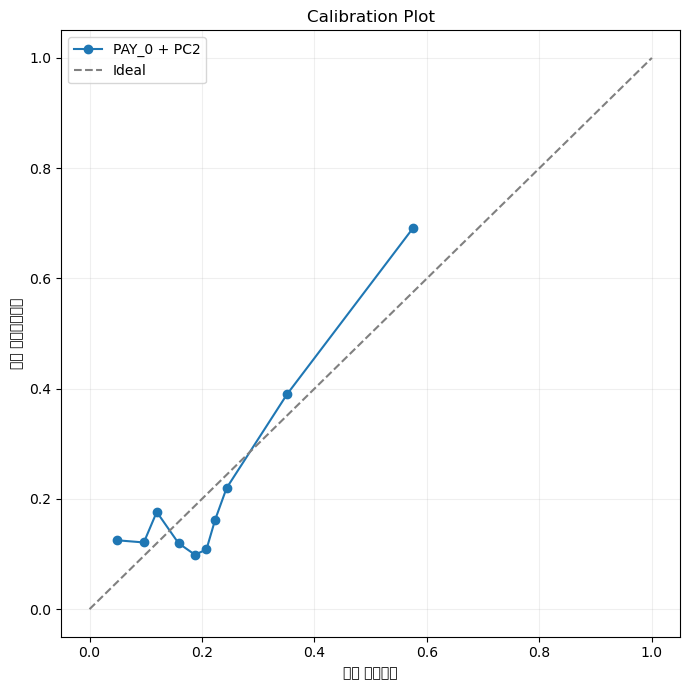

   mean_predicted_prob  actual_default_rate
0             0.048549             0.125000
1             0.096600             0.121000
2             0.119537             0.176333
3             0.158247             0.119667
4             0.187548             0.098667
5             0.207940             0.108333
6             0.223418             0.162333
7             0.243736             0.219667
8             0.351366             0.390000
9             0.575054             0.691000


In [43]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_target, prob_pay0_pc2, n_bins=10, strategy='quantile')

plt.figure(figsize=(7, 7))
plt.plot(prob_pred, prob_true, marker='o', label='PAY_0 + PC2')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal')
plt.xlabel('평균 예측확률')
plt.ylabel('실제 채무불이행률')
plt.title('Calibration Plot')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(pd.DataFrame({
    'mean_predicted_prob': prob_pred,
    'actual_default_rate': prob_true
}))


      model   roc_auc  brier_score
0  original  0.715505     0.145783
1   sigmoid  0.715524     0.145765
2  isotonic  0.723088     0.140176


C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\2118282268.py:48: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\2118282268.py:48: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\2118282268.py:48: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\2118282268.py:48: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\2118282268.py:48: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19816\2118282268.py:48: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missi

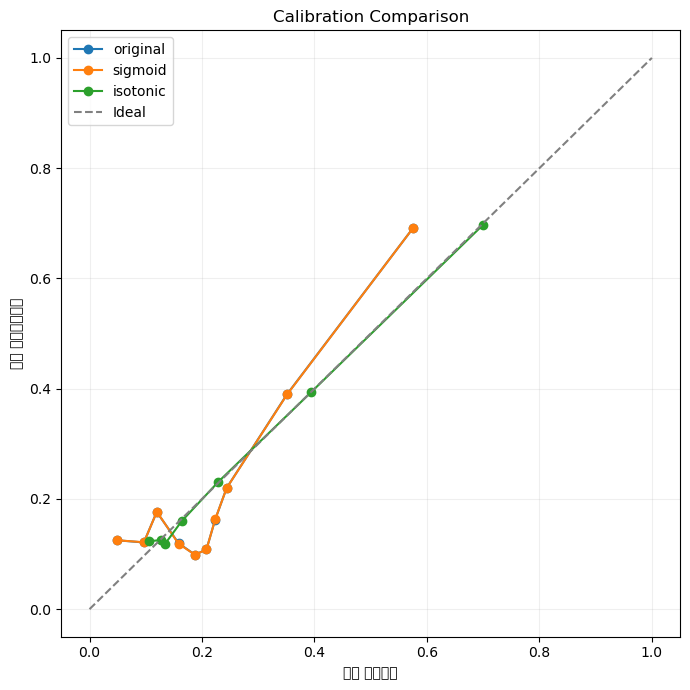

In [44]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
import pandas as pd
import matplotlib.pyplot as plt

X_pay0_pc2 = pd.DataFrame({
    'PAY_0': X_features['PAY_0'],
    'PC2': pca_df['PC2']
})

base_lr = LogisticRegression(max_iter=1000, random_state=42)

cal_sigmoid = CalibratedClassifierCV(base_lr, method='sigmoid', cv=5)
cal_sigmoid.fit(X_pay0_pc2, y_target)
prob_sigmoid = cal_sigmoid.predict_proba(X_pay0_pc2)[:, 1]

cal_isotonic = CalibratedClassifierCV(base_lr, method='isotonic', cv=5)
cal_isotonic.fit(X_pay0_pc2, y_target)
prob_isotonic = cal_isotonic.predict_proba(X_pay0_pc2)[:, 1]

result = pd.DataFrame({
    'model': ['original', 'sigmoid', 'isotonic'],
    'roc_auc': [
        roc_auc_score(y_target, prob_pay0_pc2),
        roc_auc_score(y_target, prob_sigmoid),
        roc_auc_score(y_target, prob_isotonic)
    ],
    'brier_score': [
        brier_score_loss(y_target, prob_pay0_pc2),
        brier_score_loss(y_target, prob_sigmoid),
        brier_score_loss(y_target, prob_isotonic)
    ]
})
print(result)

plt.figure(figsize=(7, 7))
for name, prob in [('original', prob_pay0_pc2), ('sigmoid', prob_sigmoid), ('isotonic', prob_isotonic)]:
    prob_true, prob_pred = calibration_curve(y_target, prob, n_bins=10, strategy='quantile')
    plt.plot(prob_pred, prob_true, marker='o', label=name)

plt.plot([0, 1], [0, 1], '--', color='gray', label='Ideal')
plt.xlabel('평균 예측확률')
plt.ylabel('실제 채무불이행률')
plt.title('Calibration Comparison')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [45]:
iso_score_df = pd.DataFrame({
    'default': y_target,
    'risk_score': prob_isotonic
})

iso_cutoff = iso_score_df['risk_score'].quantile(0.9)
iso_top10 = iso_score_df[iso_score_df['risk_score'] >= iso_cutoff]

print(f"isotonic 상위 10% 컷오프: {iso_cutoff:.4f}")
print(f"isotonic 상위 10% 고객 수: {len(iso_top10)}")
print(f"isotonic 상위 10% 실제 채무불이행률: {iso_top10['default'].mean():.4f}")
print(f"전체 평균 채무불이행률: {iso_score_df['default'].mean():.4f}")


isotonic 상위 10% 컷오프: 0.5817
isotonic 상위 10% 고객 수: 3109
isotonic 상위 10% 실제 채무불이행률: 0.6893
전체 평균 채무불이행률: 0.2212


In [46]:
final_summary = pd.DataFrame([
    {
        '모델': 'RFC + SMOTE',
        '설명력': '낮음',
        'Precision': 0.5105,
        'Recall': 0.4770,
        'F1': 0.4932,
        'ROC_AUC': 0.7443,
        '확률보정': '미확인',
        '고위험군 선별 해석': '어려움'
    },
    {
        '모델': 'PAY_0 + PC2 @ 0.3',
        '설명력': '높음',
        'Precision': 0.5775,
        'Recall': 0.4542,
        'F1': 0.5085,
        'ROC_AUC': 0.7155,
        '확률보정': '보정 전',
        '고위험군 선별 해석': '가능'
    },
    {
        '모델': 'PAY_0 + PC2 + Isotonic',
        '설명력': '높음',
        'Precision': None,
        'Recall': None,
        'F1': None,
        'ROC_AUC': 0.7231,
        '확률보정': '우수',
        '고위험군 선별 해석': '상위 10% default rate = 0.6893'
    }
])

print(final_summary)

                       모델 설명력  Precision  Recall      F1  ROC_AUC  확률보정  \
0             RFC + SMOTE  낮음     0.5105  0.4770  0.4932   0.7443   미확인   
1       PAY_0 + PC2 @ 0.3  높음     0.5775  0.4542  0.5085   0.7155  보정 전   
2  PAY_0 + PC2 + Isotonic  높음        NaN     NaN     NaN   0.7231    우수   

                     고위험군 선별 해석  
0                           어려움  
1                            가능  
2  상위 10% default rate = 0.6893  


## 최종 결론

- 예측 성능만 보면 `RFC + SMOTE`가 높은 `Recall(0.4770)`을 보여 채무불이행 고객 탐지에 유리했다.
- 그러나 `PAY_0 + PC2` 해석형 모델은 `threshold=0.3`에서 `F1=0.5085`로 더 높았고, 변수 의미를 설명할 수 있다는 장점이 있다.
- 특히 `PC2`는 `PAY_0~PAY_6` 중심의 연체 이력 축으로 해석되며, `PAY_0`에 추가적인 설명력을 제공했다.
- `Isotonic` 보정 후 `ROC-AUC=0.7231`, `Brier score=0.1402`로 확률 품질이 개선되었고, 상위 10% 고위험군의 실제 채무불이행률은 `68.93%`였다.
- 따라서 실무 적용 관점에서는:
  - 채무불이행 고객 최대 탐지가 목표이면 `RFC + SMOTE`
  - 해석 가능성과 확률 기반 고객 선별이 중요하면 `PAY_0 + PC2 + Isotonic`


In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pandas as pd

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

rows = []
for th in thresholds:
    y_pred_th = (y_prob_smote >= th).astype(int)
    rows.append({
        'threshold': th,
        'precision': round(precision_score(y_test, y_pred_th), 4),
        'recall': round(recall_score(y_test, y_pred_th), 4),
        'f1': round(f1_score(y_test, y_pred_th), 4),
    })

threshold_df = pd.DataFrame(rows)
print("=== RFC + SMOTE Threshold 비교 ===")
print(threshold_df)

# 가장 적절하다고 판단한 threshold 하나를 넣어서 상세 결과 확인
best_th = 0.3
y_pred_best = (y_prob_smote >= best_th).astype(int)

print(f"\n=== RFC + SMOTE @ threshold={best_th} ===")
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best, target_names=['정상(0)', '채무불이행(1)']))

=== RFC + SMOTE Threshold 비교 ===
   threshold  precision  recall      f1
0        0.1     0.2431  0.9699  0.3887
1        0.2     0.2847  0.8651  0.4284
2        0.3     0.3469  0.7151  0.4671
3        0.4     0.4250  0.5961  0.4962
4        0.5     0.5039  0.4876  0.4956

=== RFC + SMOTE @ threshold=0.3 ===
[[2886 1787]
 [ 378  949]]
              precision    recall  f1-score   support

       정상(0)       0.88      0.62      0.73      4673
    채무불이행(1)       0.35      0.72      0.47      1327

    accuracy                           0.64      6000
   macro avg       0.62      0.67      0.60      6000
weighted avg       0.77      0.64      0.67      6000



In [48]:
print("=== RFC + SMOTE 모델 ===")
print(rfc_smote)

print("\n=== 하이퍼파라미터 ===")
print(rfc_smote.get_params())

=== RFC + SMOTE 모델 ===
RandomForestClassifier(random_state=42)

=== 하이퍼파라미터 ===
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [49]:
rfc_smote

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric